# Graph-based MCS: matching config comparison

Compares different blends of atom/bond compatibility functions for Maximum Common Substructure detection.

| Config | Atom matching | Bond matching | Murcko pre-processing |
|---|---|---|---|
| `strict` | element | bond type | no |
| `element_only` | element | any | no |
| `aromatic` | element + aromaticity | bond type | no |
| `full_atom` | element + aromaticity + charge | bond type | no |
| `heavy_atom` | any | any | no |
| `ring_aware` | element | bond type + ring membership | no |
| `murcko_strict` | element | bond type | yes |
| `murcko_element` | element | any | yes |
| `murcko_heavy` | any | any | yes |

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import display
import pandas as pd

from stratosampler.mcs import (
    compare_configs,
    find_mcs_iterative,
    to_murcko,
    PRESETS,
)

## Molecule sets

Two sets chosen to stress-test different aspects of the configs:
- **NSAIDs**: arylacetic/arylpropionic acids — shared aryl-COOH motif, Murcko scaffolds differ in ring count (~13–18 heavy atoms each; exact BK is fast)
- **Phenylethylamines**: dopamine/epinephrine/phenylephrine — catechol/phenol core, differences in ring substitution and N-methylation (~9–13 heavy atoms each)

> **Note on scale**: exact Bron-Kerbosch is used for correspondence graphs ≤ 300 nodes (roughly molecules ≤ 17 heavy atoms each for pairwise). Larger pairs fall back to greedy approximation — a lower bound. For larger molecules, Murcko preprocessing is recommended.

In [18]:
SETS = {
    # Arylacetic / arylpropionic acid NSAIDs — shared aryl-CH2-COOH scaffold
    "NSAIDs": {
        "Aspirin":    "CC(=O)Oc1ccccc1C(=O)O",
        "Ibuprofen":  "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
        "Naproxen":   "COc1ccc2cc(ccc2c1)C(C)C(=O)O",
        "Ketoprofen": "OC(=O)C(C)c1cccc(c1)C(=O)c1ccccc1",
    },
    # Phenylethylamines — catechol/phenol + ethanolamine core
    "Phenylethylamines": {
        "Dopamine":      "NCCc1ccc(O)c(O)c1",
        "Epinephrine":   "CNC[C@@H](O)c1ccc(O)c(O)c1",
        "Phenylephrine": "CNC[C@@H](O)c1cccc(O)c1",
    },
}

# Parse all sets
mol_sets = {
    name: {n: Chem.MolFromSmiles(s) for n, s in molecules.items()}
    for name, molecules in SETS.items()
}

# Quick sanity: print heavy atom counts
for set_name, mols_dict in mol_sets.items():
    counts = {n: m.GetNumHeavyAtoms() for n, m in mols_dict.items()}
    print(f"{set_name}: {counts}")

NSAIDs: {'Aspirin': 13, 'Ibuprofen': 15, 'Naproxen': 17, 'Ketoprofen': 19}
Phenylethylamines: {'Dopamine': 11, 'Epinephrine': 13, 'Phenylephrine': 12}


## Helper: draw molecules with highlighted MCS atoms

In [19]:
def draw_mcs_grid(mols, names, mapping, title="", img_size=(350, 280)):
    """Draw molecules side-by-side with MCS atoms highlighted."""
    mcs_size = len(mapping[0]) if mapping and mapping[0] else 0
    highlight_lists = [list(atoms) for atoms in mapping]
    legend = f"{title}  |  MCS = {mcs_size} atoms"
    legends = [f"{n}\n({mols[i].GetNumHeavyAtoms()} heavy atoms)" for i, n in enumerate(names)]

    return Draw.MolsToGridImage(
        mols,
        molsPerRow=len(mols),
        subImgSize=img_size,
        highlightAtomLists=highlight_lists,
        legends=legends,
    )


def draw_all_configs(mol_dict, configs=None, img_size=(350, 280)):
    """Run compare_configs and draw one grid per config."""
    mols  = list(mol_dict.values())
    names = list(mol_dict.keys())

    if configs is None:
        configs = list(PRESETS.values())

    df = compare_configs(mols, mol_names=names, configs=configs)

    for _, row in df.iterrows():
        cfg_name    = row["config"]
        description = row["description"]
        mapping     = row["mapping"]

        # For Murcko configs use the scaffold molecules
        if PRESETS[cfg_name].use_murcko:
            display_mols  = [to_murcko(m) or m for m in mols]
            display_names = [f"{n} [Murcko]" for n in names]
        else:
            display_mols  = mols
            display_names = names

        title = f"{cfg_name} — {description}"
        img = draw_mcs_grid(display_mols, display_names, mapping, title=title, img_size=img_size)
        print(title)
        print(f"  MCS size: {row['mcs_size']}   coverage: {row['coverage']:.2%}   jaccard: {row['jaccard']:.4f}")
        display(img)
        print()

    return df

## 1. NSAIDs

Full structures


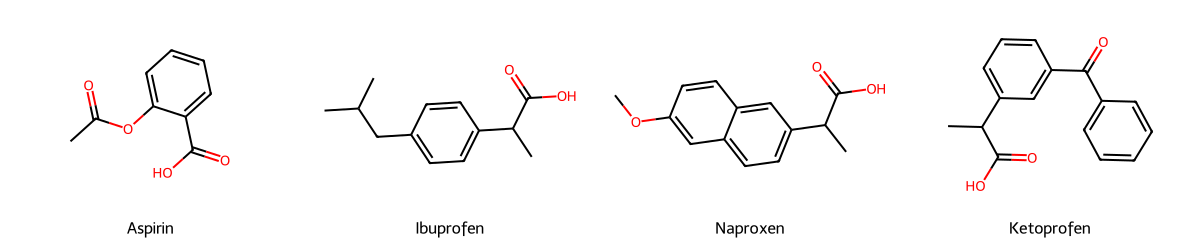

Murcko scaffolds


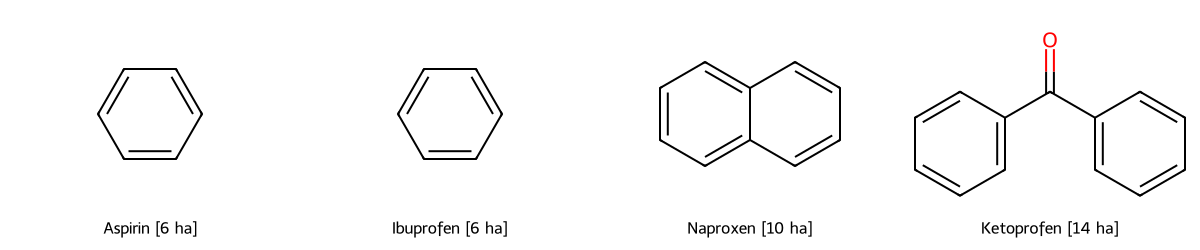

In [20]:
nsaid_mols  = list(mol_sets["NSAIDs"].values())
nsaid_names = list(mol_sets["NSAIDs"].keys())

print("Full structures")
display(Draw.MolsToGridImage(
    nsaid_mols, molsPerRow=4, subImgSize=(300, 250), legends=nsaid_names
))

print("Murcko scaffolds")
murcko_mols = [to_murcko(m) or m for m in nsaid_mols]
display(Draw.MolsToGridImage(
    murcko_mols, molsPerRow=4, subImgSize=(300, 250),
    legends=[f"{n} [{m.GetNumHeavyAtoms()} ha]" for n, m in zip(nsaid_names, murcko_mols)],
))

strict — Exact element + exact bond order
  MCS size: 7   coverage: 53.85%   jaccard: 0.1628


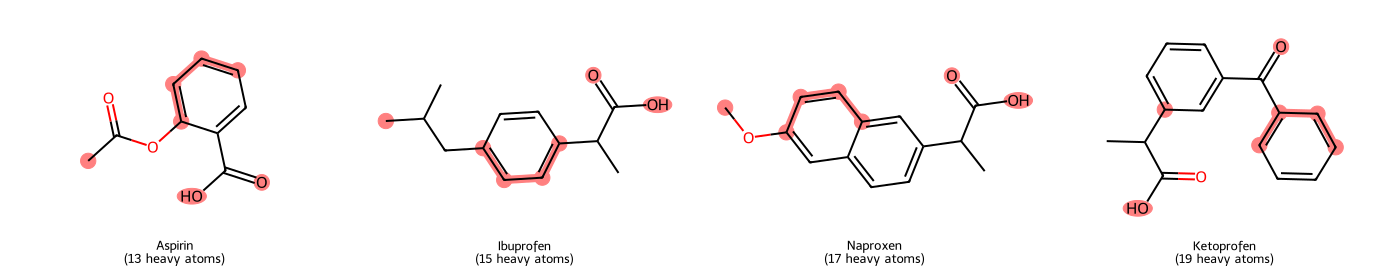


element_only — Exact element, ignore bond order
  MCS size: 6   coverage: 46.15%   jaccard: 0.1304


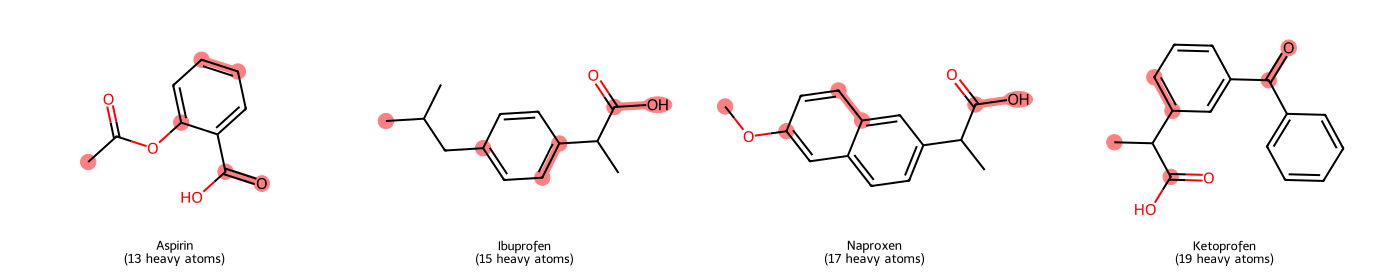


aromatic — Element + aromaticity flag, exact bond order
  MCS size: 6   coverage: 46.15%   jaccard: 0.1304


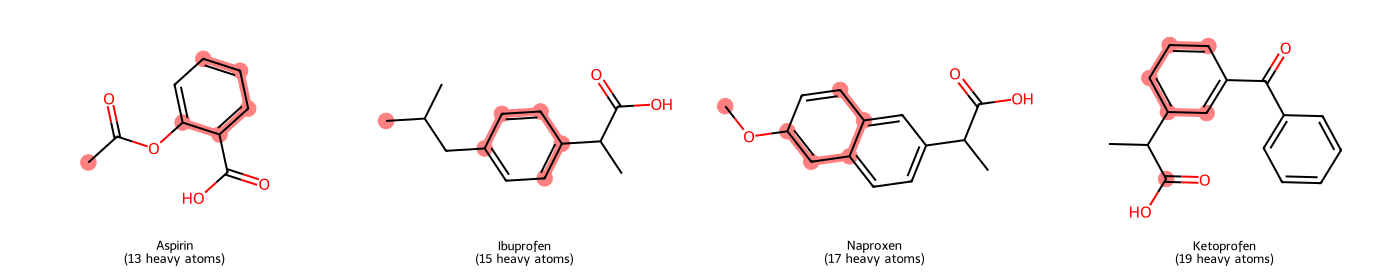


full_atom — Element + aromaticity + charge, exact bond order
  MCS size: 6   coverage: 46.15%   jaccard: 0.1304


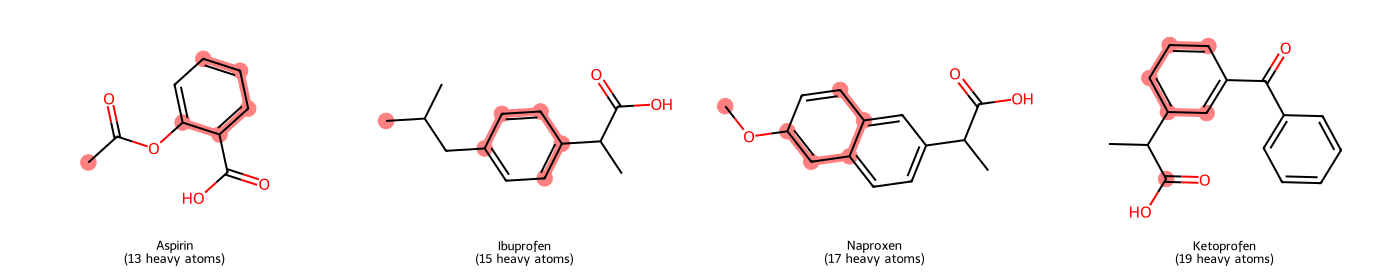


heavy_atom — Any heavy atom, ignore bond order — maximum topology overlap
  MCS size: 10   coverage: 76.92%   jaccard: 0.2941


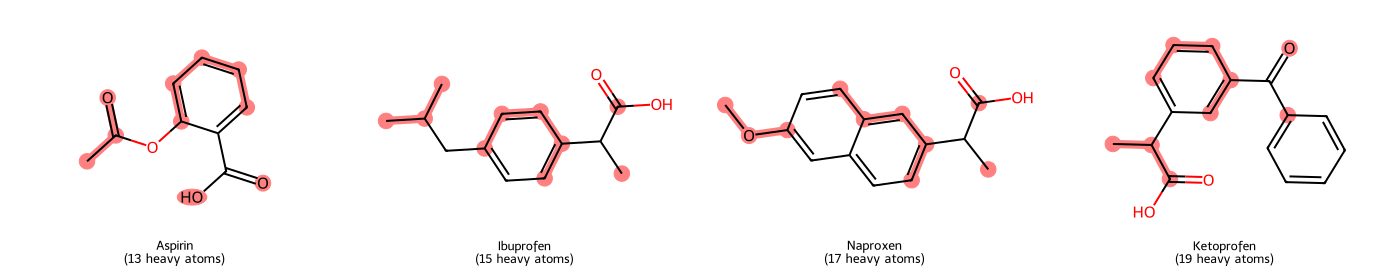


ring_aware — Exact element + bond order + ring membership must agree
  MCS size: 7   coverage: 53.85%   jaccard: 0.1628


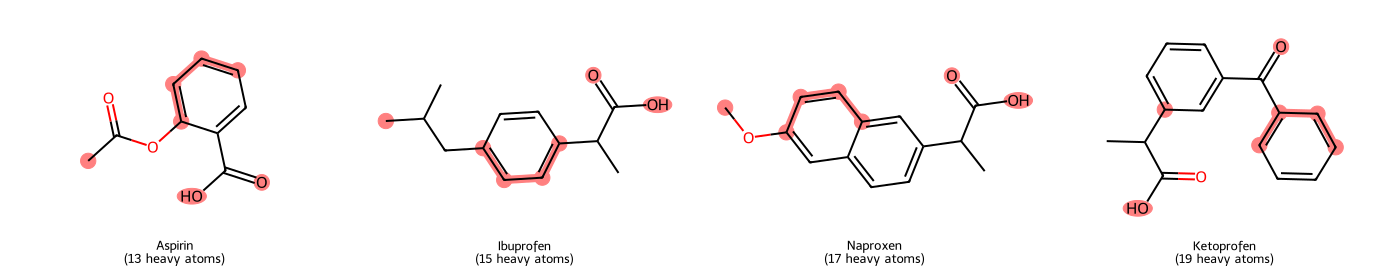


murcko_strict — Strict matching on Murcko scaffolds only
  MCS size: 6   coverage: 100.00%   jaccard: 0.3333


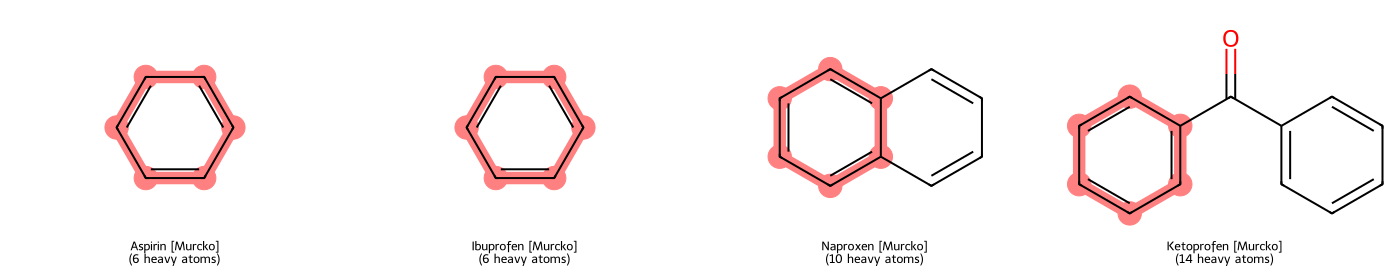


murcko_element — Element-only matching on Murcko scaffolds
  MCS size: 6   coverage: 100.00%   jaccard: 0.3333


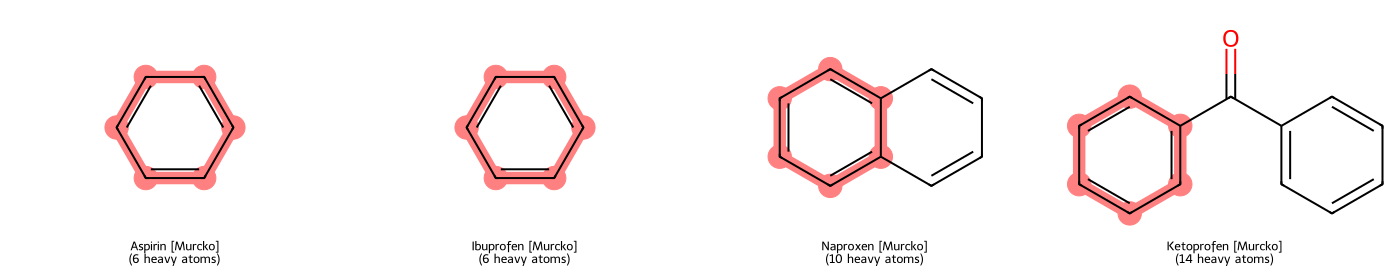


murcko_heavy — Maximum topology overlap on Murcko scaffolds
  MCS size: 6   coverage: 100.00%   jaccard: 0.3333


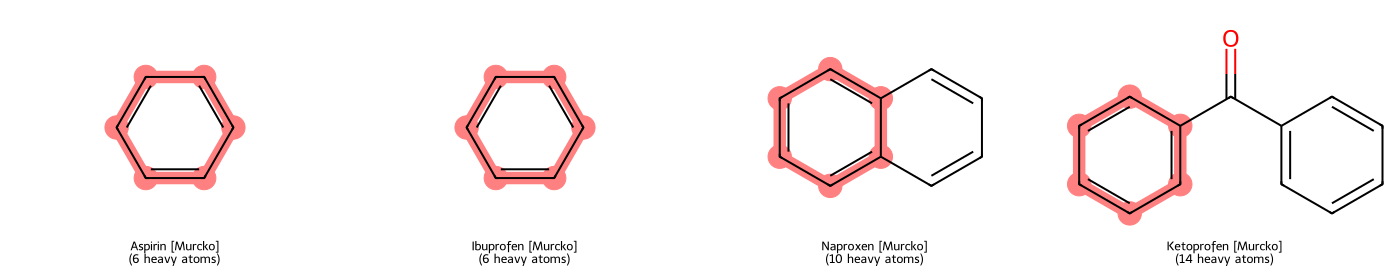

In [21]:
nsaid_df = draw_all_configs(mol_sets["NSAIDs"])

In [22]:
nsaid_df[[
    "config", "description", "mcs_size", "min_mol_size", "coverage", "jaccard", "approximate"
]].style.background_gradient(subset=["coverage", "jaccard"], cmap="YlGn")

,config,description,mcs_size,min_mol_size,coverage,jaccard,approximate
0,strict,Exact element + exact bond order,7,13,0.538500,0.162800,True
1,element_only,"Exact element, ignore bond order",6,13,0.461500,0.130400,True
2,aromatic,"Element + aromaticity flag, exact bond order",6,13,0.461500,0.130400,True
3,full_atom,"Element + aromaticity + charge, exact bond order",6,13,0.461500,0.130400,True
4,heavy_atom,"Any heavy atom, ignore bond order — maximum topology overlap",10,13,0.769200,0.294100,True
5,ring_aware,Exact element + bond order + ring membership must agree,7,13,0.538500,0.162800,True
6,murcko_strict,Strict matching on Murcko scaffolds only,6,6,1.000000,0.333300,False
7,murcko_element,Element-only matching on Murcko scaffolds,6,6,1.000000,0.333300,False
8,murcko_heavy,Maximum topology overlap on Murcko scaffolds,6,6,1.000000,0.333300,False


## 2. Phenylethylamines

In [23]:
pea_mols  = list(mol_sets["Phenylethylamines"].values())
pea_names = list(mol_sets["Phenylethylamines"].keys())

print("Full structures")
display(Draw.MolsToGridImage(isk has 23 cells total.
    pea_mols, molsPerRow=3, subImgSize=(300, 250), legends=pea_names
))

print("Murcko scaffolds")
pea_murcko = [to_murcko(m) or m for m in pea_mols]
display(Draw.MolsToGridImage(
    pea_murcko, molsPerRow=3, subImgSize=(300, 250),
    legends=[f"{n} [{m.GetNumHeavyAtoms()} ha]" for n, m in zip(pea_names, pea_murcko)],
))

SyntaxError: invalid syntax. Perhaps you forgot a comma? (513389388.py, line 5)

strict — Exact element + exact bond order
  MCS size: 10   coverage: 90.91%   jaccard: 0.6250


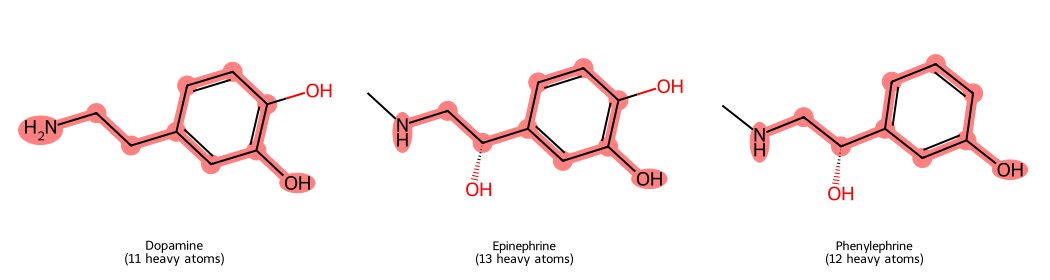


element_only — Exact element, ignore bond order
  MCS size: 10   coverage: 90.91%   jaccard: 0.6250


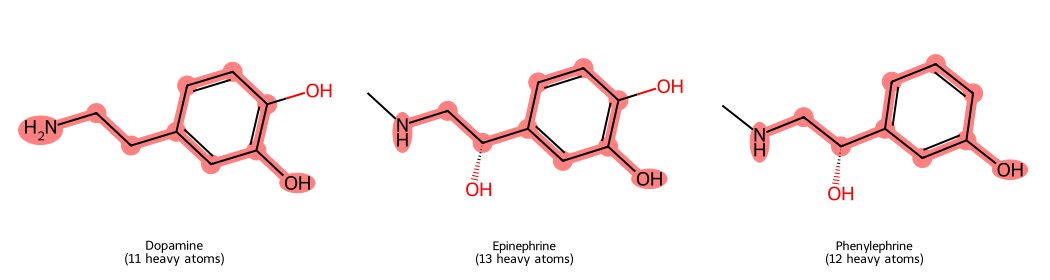


aromatic — Element + aromaticity flag, exact bond order
  MCS size: 7   coverage: 63.64%   jaccard: 0.3182


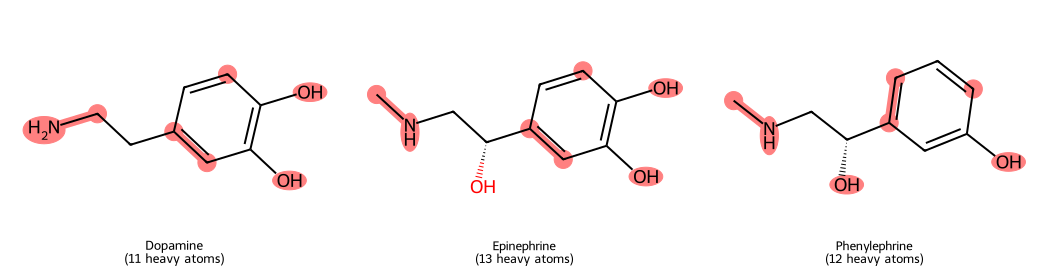


full_atom — Element + aromaticity + charge, exact bond order
  MCS size: 7   coverage: 63.64%   jaccard: 0.3182


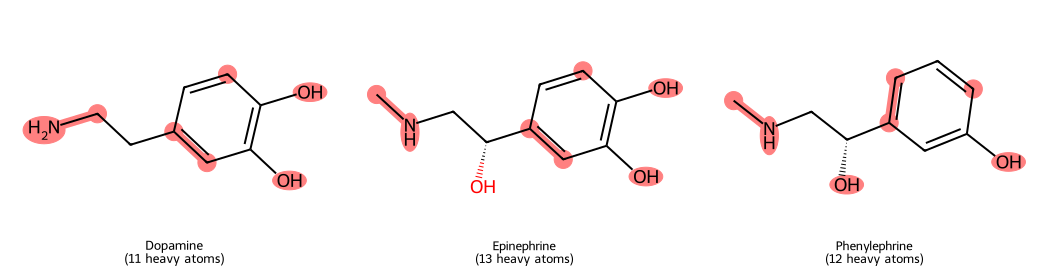


heavy_atom — Any heavy atom, ignore bond order — maximum topology overlap
  MCS size: 9   coverage: 81.82%   jaccard: 0.5000


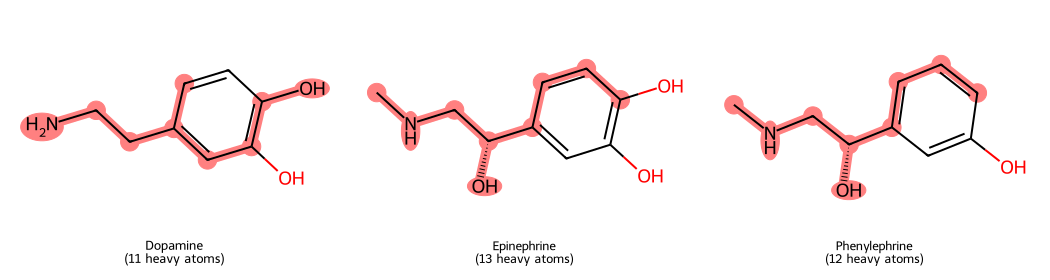


ring_aware — Exact element + bond order + ring membership must agree
  MCS size: 10   coverage: 90.91%   jaccard: 0.6250


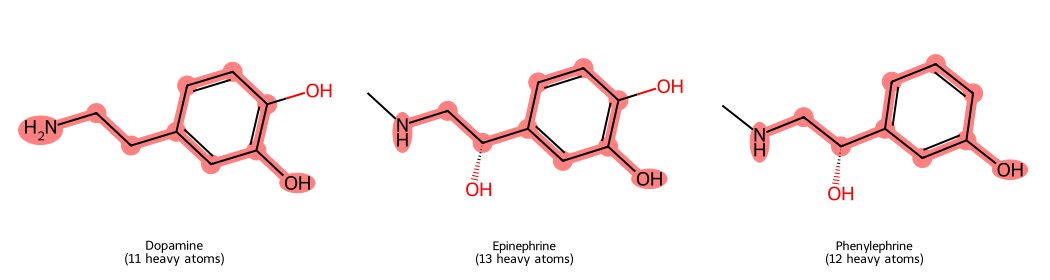


murcko_strict — Strict matching on Murcko scaffolds only
  MCS size: 6   coverage: 100.00%   jaccard: 1.0000


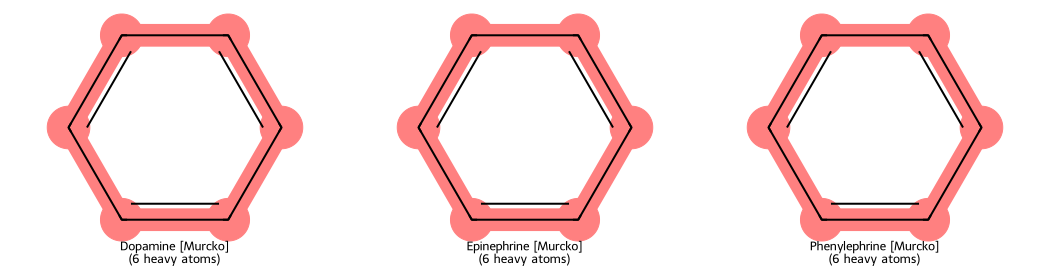


murcko_element — Element-only matching on Murcko scaffolds
  MCS size: 6   coverage: 100.00%   jaccard: 1.0000


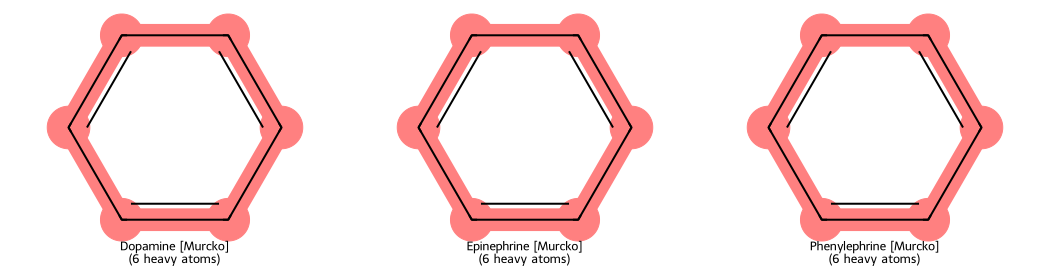


murcko_heavy — Maximum topology overlap on Murcko scaffolds
  MCS size: 6   coverage: 100.00%   jaccard: 1.0000


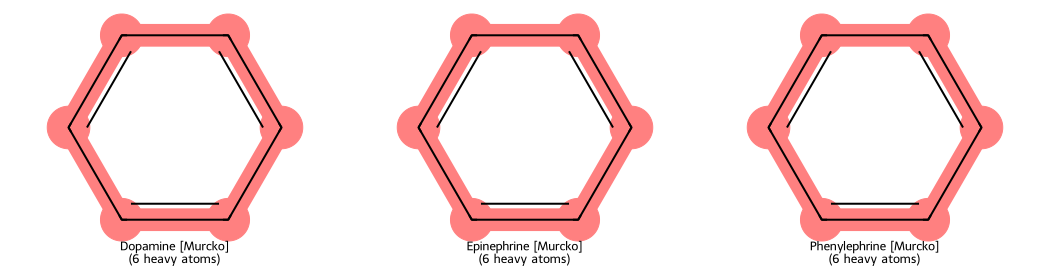

In [ ]:
pea_df = draw_all_configs(mol_sets["Phenylethylamines"])

In [ ]:
pea_df[[
    "config", "description", "mcs_size", "min_mol_size", "coverage", "jaccard", "approximate"
]].style.background_gradient(subset=["coverage", "jaccard"], cmap="YlGn")

,config,description,mcs_size,min_mol_size,coverage,jaccard,approximate
0,strict,Exact element + exact bond order,10,11,0.909100,0.625000,False
1,element_only,"Exact element, ignore bond order",10,11,0.909100,0.625000,False
2,aromatic,"Element + aromaticity flag, exact bond order",7,11,0.636400,0.318200,True
3,full_atom,"Element + aromaticity + charge, exact bond order",7,11,0.636400,0.318200,True
4,heavy_atom,"Any heavy atom, ignore bond order — maximum topology overlap",9,11,0.818200,0.500000,True
5,ring_aware,Exact element + bond order + ring membership must agree,10,11,0.909100,0.625000,False
6,murcko_strict,Strict matching on Murcko scaffolds only,6,6,1.000000,1.000000,False
7,murcko_element,Element-only matching on Murcko scaffolds,6,6,1.000000,1.000000,False
8,murcko_heavy,Maximum topology overlap on Murcko scaffolds,6,6,1.000000,1.000000,False


## 3. Side-by-side config comparison

MCS coverage across all configs for both molecule sets.

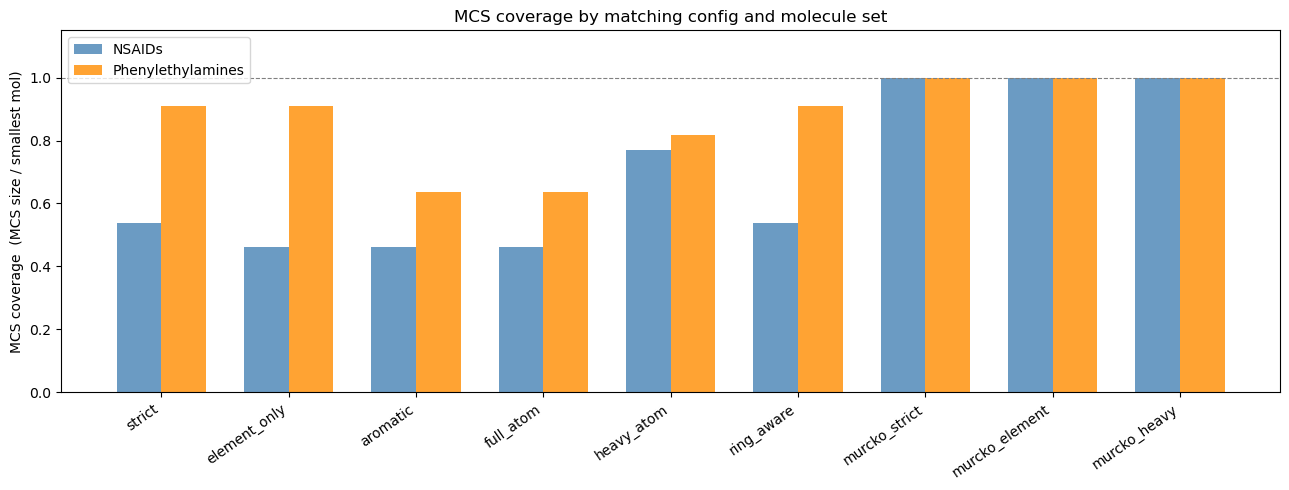

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

configs       = list(PRESETS.keys())
nsaid_cov     = nsaid_df.set_index("config").loc[configs, "coverage"].values
pea_cov       = pea_df.set_index("config").loc[configs, "coverage"].values

x     = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, nsaid_cov, width, label="NSAIDs",             color="steelblue",  alpha=0.8)
ax.bar(x + width/2, pea_cov,   width, label="Phenylethylamines",  color="darkorange", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("MCS coverage  (MCS size / smallest mol)")
ax.set_title("MCS coverage by matching config and molecule set")
ax.legend()
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
plt.tight_layout()
plt.show()

## 4. Custom config

You can define your own blend and pass it directly to `compare_configs`.

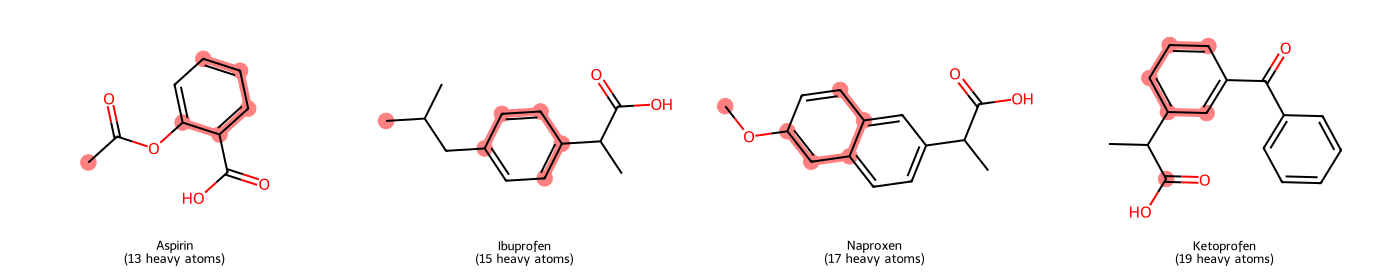

In [ ]:
from stratosampler.mcs import MCSConfig, atom_aromatic, bond_any

custom = MCSConfig(
    name="custom_aromatic_any",
    atom_compat=atom_aromatic,
    bond_compat=bond_any,
    use_murcko=False,
    description="Aromatic-aware atoms, any bond order",
)

df_custom = compare_configs(nsaid_mols, mol_names=nsaid_names, configs=[custom])
mapping = df_custom.iloc[0]["mapping"]

img = draw_mcs_grid(nsaid_mols, nsaid_names, mapping, title=custom.name)
display(img)

## 5. Kinase inhibitors — pairwise 1:1 vs imatinib

Imatinib (BCR-ABL/c-Kit) is the reference. Each compound below is compared individually as a 2-molecule MCS across all configs.

Compounds span a spectrum of structural distance from the reference:

| Compound | Target(s) | Expected similarity |
|---|---|---|
| Nilotinib | BCR-ABL | High — shares aminopyrimidine + benzamide scaffold |
| Ponatinib | BCR-ABL T315I | High — shares core, adds ethynyl bridge |
| Dasatinib | BCR-ABL / Src | Medium — thiazole linker, shares pyrimidine |
| Bosutinib | BCR-ABL / Src | Medium — quinoline scaffold |
| Gefitinib | EGFR | Low–medium — quinazoline, similar side chains |
| Erlotinib | EGFR | Low–medium — quinazoline |
| Sunitinib | VEGFR / PDGFR | Low — oxindole scaffold |
| Sorafenib | VEGFR / BRAF | Low — diaryl urea |

> **Scale note**: kinase inhibitors carry 30–50 heavy atoms. Full-structure correspondence graphs exceed the exact BK node limit and fall back to greedy approximation (lower bound). Murcko preprocessing reduces scaffold sizes to 15–25 atoms and usually stays within the exact range.

In [ ]:
KINASE_SMILES = {
    "Imatinib":  "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",
    "Nilotinib": "Cc1ccc(NC(=O)c2ccc(CF)cc2)cc1Nc1nccc(-c2cc(C(F)(F)F)ccc2F)n1",  # AMN107
    "Ponatinib": "Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)cc2Nc2nccc(-c3cn(C)c4ccccc34)n2)cc1C#C",
    "Dasatinib": "Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO)CC2)n1",
    "Bosutinib": "COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCCCN1CCC(N)CC1",
    "Gefitinib": "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1",
    "Erlotinib": "C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1",
    "Sunitinib": "CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C",
    "Sorafenib": "CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1",
}

kinase_mols = {name: Chem.MolFromSmiles(smi) for name, smi in KINASE_SMILES.items()}

# Sanity check
for name, mol in kinase_mols.items():
    status = f"{mol.GetNumHeavyAtoms()} ha" if mol else "PARSE FAILED"
    print(f"  {name:<14} {status}")

ref_name = "Imatinib"
ref_mol  = kinase_mols[ref_name]

print("\nMurcko scaffold sizes:")
for name, mol in kinase_mols.items():
    sc = to_murcko(mol)
    size = sc.GetNumHeavyAtoms() if sc else "no rings"
    print(f"  {name:<14} {size}")

  Imatinib       37 ha
  Nilotinib      36 ha
  Ponatinib      43 ha
  Dasatinib      33 ha
  Bosutinib      32 ha
  Gefitinib      31 ha
  Erlotinib      29 ha
  Sunitinib      29 ha
  Sorafenib      32 ha

Murcko scaffold sizes:
  Imatinib       35
  Nilotinib      28
  Ponatinib      38
  Dasatinib      27
  Bosutinib      27
  Gefitinib      27
  Erlotinib      17
  Sunitinib      16
  Sorafenib      23


In [ ]:
def compare_ref_vs_all(ref_mol, query_mols, ref_name="ref", configs=None):
    """Run pairwise MCS: ref vs each query mol, across all configs.

    Returns a DataFrame with columns:
        compound, config, description, mcs_size, ref_size, query_size,
        coverage_ref, coverage_query, jaccard, approximate
    where coverage_ref  = MCS / ref heavy atoms
          coverage_query = MCS / query heavy atoms
    """
    if configs is None:
        configs = list(PRESETS.values())

    rows = []
    for qname, qmol in query_mols.items():
        df = compare_configs([ref_mol, qmol], mol_names=[ref_name, qname], configs=configs)
        for _, r in df.iterrows():
            ref_size   = r["mol_sizes"][0]
            query_size = r["mol_sizes"][1]
            mcs_size   = r["mcs_size"]
            rows.append({
                "compound":       qname,
                "config":         r["config"],
                "description":    r["description"],
                "mcs_size":       mcs_size,
                "ref_size":       ref_size,
                "query_size":     query_size,
                "coverage_ref":   round(mcs_size / ref_size,   4) if ref_size   else 0.0,
                "coverage_query": round(mcs_size / query_size, 4) if query_size else 0.0,
                "jaccard":        r["jaccard"],
                "approximate":    r["approximate"],
                "mapping":        r["mapping"],
            })

    return pd.DataFrame(rows)


query_mols = {k: v for k, v in kinase_mols.items() if k != ref_name}
kinase_df  = compare_ref_vs_all(ref_mol, query_mols, ref_name=ref_name)

kinase_df[[
    "compound", "config", "mcs_size", "ref_size", "query_size",
    "coverage_ref", "coverage_query", "jaccard", "approximate"
]]

,compound,config,mcs_size,ref_size,query_size,coverage_ref,coverage_query,jaccard,approximate
0,Nilotinib,strict,23,37,36,0.6216,0.6389,0.4600,True
1,Nilotinib,element_only,23,37,36,0.6216,0.6389,0.4600,True
2,Nilotinib,aromatic,24,37,36,0.6486,0.6667,0.4898,True
3,Nilotinib,full_atom,24,37,36,0.6486,0.6667,0.4898,True
4,Nilotinib,heavy_atom,29,37,36,0.7838,0.8056,0.6591,True
...,...,...,...,...,...,...,...,...,...
67,Sorafenib,heavy_atom,23,37,32,0.6216,0.7188,0.5000,True
68,Sorafenib,ring_aware,15,37,32,0.4054,0.4688,0.2778,True
69,Sorafenib,murcko_strict,14,35,23,0.4000,0.6087,0.3182,True
70,Sorafenib,murcko_element,16,35,23,0.4571,0.6957,0.3810,True


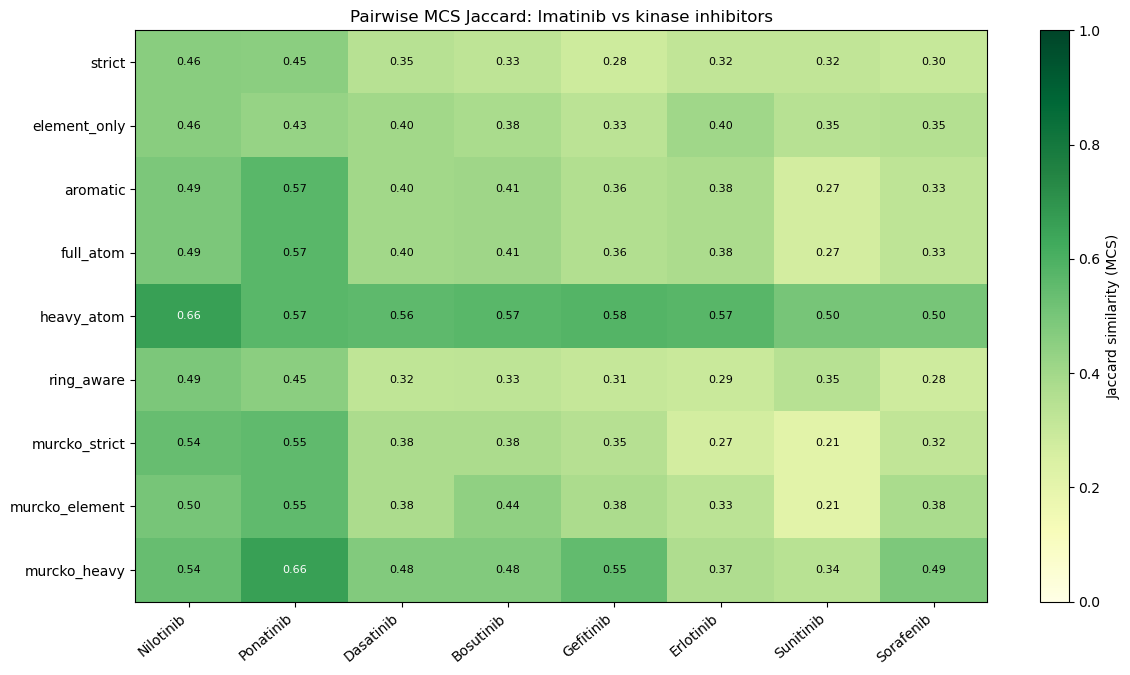

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot to (config × compound) heatmap using Jaccard as the metric
compounds   = list(query_mols.keys())
config_list = list(PRESETS.keys())

pivot = (
    kinase_df
    .pivot(index="config", columns="compound", values="jaccard")
    .reindex(index=config_list, columns=compounds)
)

fig, ax = plt.subplots(figsize=(len(compounds) * 1.4 + 1, len(config_list) * 0.65 + 1))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(compounds)))
ax.set_xticklabels(compounds, rotation=40, ha="right", fontsize=10)
ax.set_yticks(range(len(config_list)))
ax.set_yticklabels(config_list, fontsize=10)

for i in range(len(config_list)):
    for j in range(len(compounds)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                color="black" if val < 0.6 else "white")

plt.colorbar(im, ax=ax, label="Jaccard similarity (MCS)")
ax.set_title(f"Pairwise MCS Jaccard: {ref_name} vs kinase inhibitors")
plt.tight_layout()
plt.show()

murcko_strict: Imatinib vs Nilotinib  |  Jaccard=0.537
  MCS=22 atoms   ref=35 ha   query=28 ha   approx=True


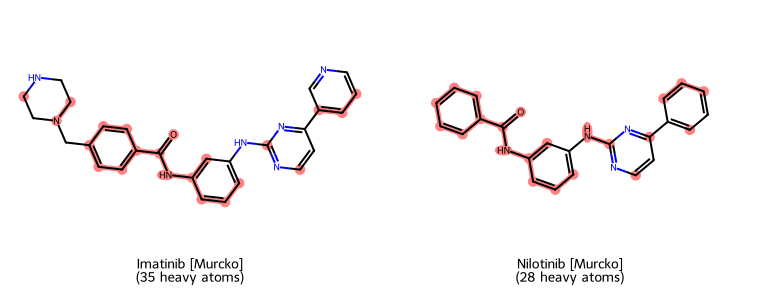


murcko_strict: Imatinib vs Ponatinib  |  Jaccard=0.553
  MCS=26 atoms   ref=35 ha   query=38 ha   approx=True


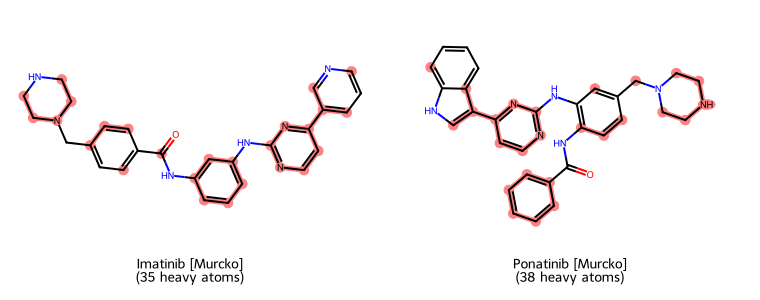


murcko_strict: Imatinib vs Dasatinib  |  Jaccard=0.378
  MCS=17 atoms   ref=35 ha   query=27 ha   approx=True


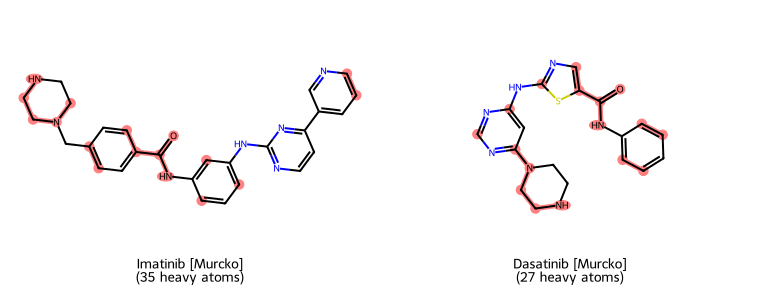


murcko_strict: Imatinib vs Bosutinib  |  Jaccard=0.378
  MCS=17 atoms   ref=35 ha   query=27 ha   approx=True


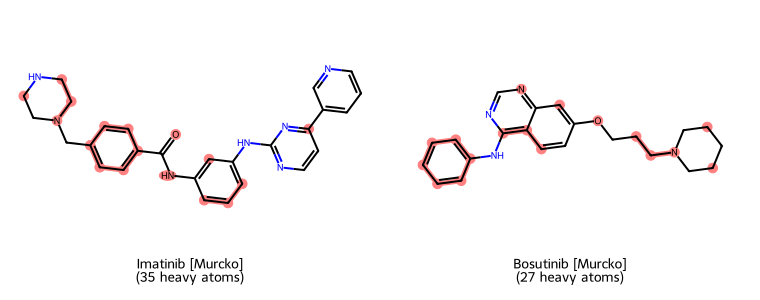


murcko_strict: Imatinib vs Gefitinib  |  Jaccard=0.348
  MCS=16 atoms   ref=35 ha   query=27 ha   approx=True


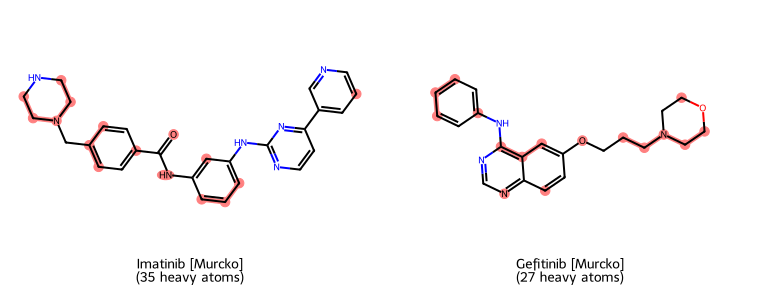


murcko_strict: Imatinib vs Erlotinib  |  Jaccard=0.268
  MCS=11 atoms   ref=35 ha   query=17 ha   approx=True


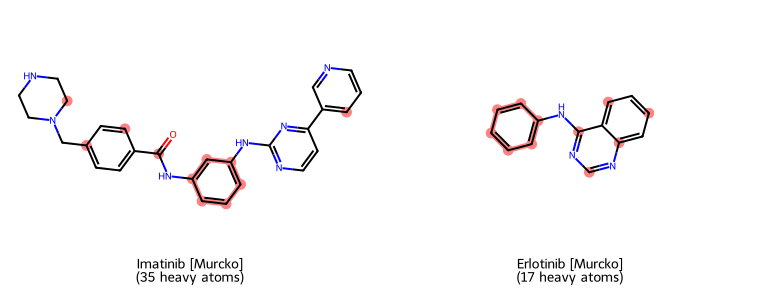


murcko_strict: Imatinib vs Sunitinib  |  Jaccard=0.214
  MCS=9 atoms   ref=35 ha   query=16 ha   approx=True


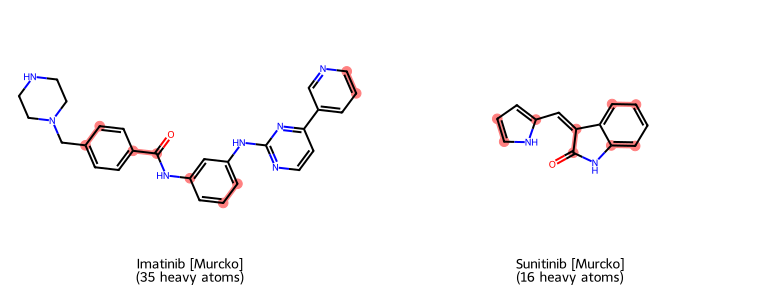


murcko_strict: Imatinib vs Sorafenib  |  Jaccard=0.318
  MCS=14 atoms   ref=35 ha   query=23 ha   approx=True


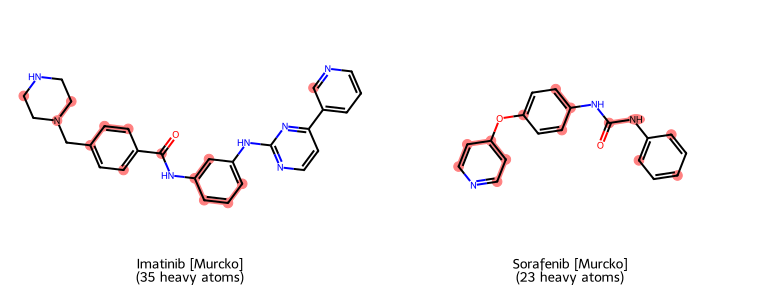

In [ ]:
# Draw highlighted MCS for each compound vs imatinib under murcko_strict
# (scaffolds keep molecule sizes manageable and give cleaner visual overlap)
VIZ_CONFIG = "murcko_strict"

subset = kinase_df[kinase_df["config"] == VIZ_CONFIG].set_index("compound")

ref_scaffold = to_murcko(ref_mol) or ref_mol

for compound, row in subset.iterrows():
    qmol      = kinase_mols[compound]
    qscaffold = to_murcko(qmol) or qmol
    mapping   = row["mapping"]

    mols  = [ref_scaffold, qscaffold]
    names = [f"{ref_name} [Murcko]", f"{compound} [Murcko]"]
    title = f"{VIZ_CONFIG}: {ref_name} vs {compound}  |  Jaccard={row['jaccard']:.3f}"

    img = draw_mcs_grid(mols, names, mapping, title=title, img_size=(380, 300))
    print(title)
    print(f"  MCS={row['mcs_size']} atoms   ref={row['ref_size']} ha   query={row['query_size']} ha"
          f"   approx={row['approximate']}")
    display(img)
    print()